In [1]:
# ---------------------------------------------------------------------------------------------------------------
# LIBRARIES
# ---------------------------------------------------------------------------------------------------------------
from datetime import date
from functools import reduce
from pathlib import Path
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
from shapely import wkt
import folium
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import *

# ---------------------------------------------------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------------------------------------------------
SITE_DATA_DIR = Path("../data/processed/traffic_site/top_100_sites.csv")
VOLUME_DATA_DIR = "../data/processed/traffic_volume"

# ---------------------------------------------------------------------------------------------------------------
# CONFIGURATIONS
# ---------------------------------------------------------------------------------------------------------------
AO_DATES = {2020: (date(2020, 1, 13), date(2020, 2, 2)),
            2021: (date(2021, 2, 1),  date(2021, 2, 21)), 
            2022: (date(2022, 1, 10), date(2022, 1, 30)),
            2023: (date(2023, 1, 9), date(2023, 1, 29)),
            2024: (date(2024, 1, 7), date(2024, 1, 28)),
            2025: (date(2025, 1, 5), date(2025, 1, 26))}

MONTH_STARTS = [
    "01-01", "02-01", "03-01", "04-01",
    "05-01", "06-01", "07-01", "08-01",
    "09-01", "10-01", "11-01", "12-01"
]

COLORS = list(mcolors.TABLEAU_COLORS.keys())

In [2]:
# ---------------------------------------------------------------------------------------------------------------
# PLOT TOP 100 CLOSEST TRAFFIC SITES
# ---------------------------------------------------------------------------------------------------------------
site_df = pd.read_csv(SITE_DATA_DIR)
site_df["geometry"] = site_df["geometry"].apply(wkt.loads)
site_gdf = gpd.GeoDataFrame(site_df, geometry="geometry", crs="EPSG:4326")

# Create map
centre = [site_gdf.geometry.y.mean(), site_gdf.geometry.x.mean()]
map = folium.Map(location=centre, zoom_start=12)

# Plot traffic sites
for row in site_gdf.itertuples():
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x],
                        radius=4,
                        fill=True,
                        popup=f"Site: {row.site_id}, Name: {row.site_name}").add_to(map)

map

In [3]:
# ---------------------------------------------------------------------------------------------------------------
# BEGIN SPARK SESSION
# ---------------------------------------------------------------------------------------------------------------
spark = SparkSession.builder.getOrCreate()

sdf = spark.read.parquet(VOLUME_DATA_DIR)

# Change schema 
new_schema = StructType([StructField("date", DateType()),
                         StructField("hour", IntegerType()),
                         StructField("site_id", IntegerType()),
                         StructField("volume", LongType())])

sdf = sdf.to(new_schema)

# Sum total volume across sites
sdf = sdf.select("date", "hour", "volume") \
         .groupBy(["date", "hour"]) \
         .agg(F.sum("volume").alias("volume")) \
         .orderBy(["date", "hour"])

# Change hour value
sdf = sdf.withColumn("hour_fixed", F.col("hour") - 1)
sdf = sdf.drop("hour")
sdf = sdf.withColumnRenamed("hour_fixed", "hour")

# Filter traffic volume during AO
conditions = [F.col("date").between(start, end) for start, end in AO_DATES.values()]
ao_sdf = sdf.filter(reduce(lambda a, b: a | b, conditions))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/16 05:19:17 WARN Utils: Your hostname, MSI, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/16 05:19:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/16 05:19:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


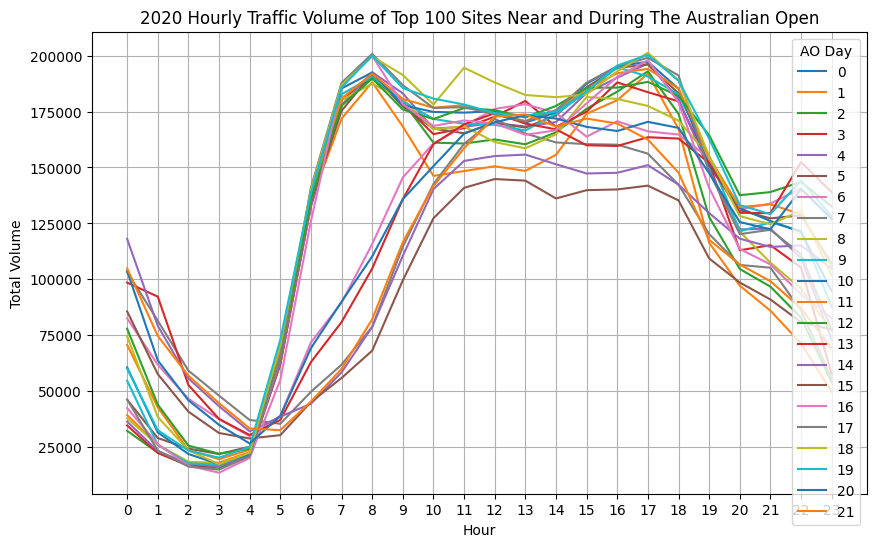

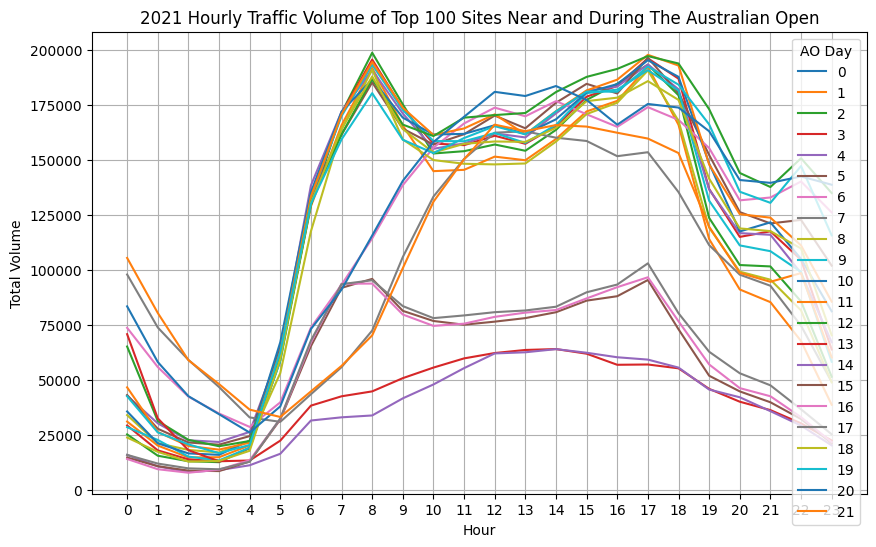

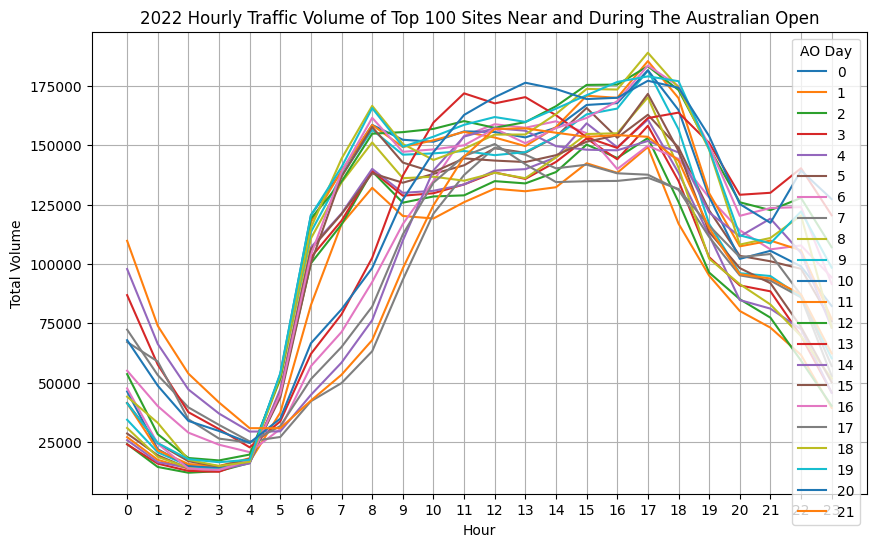

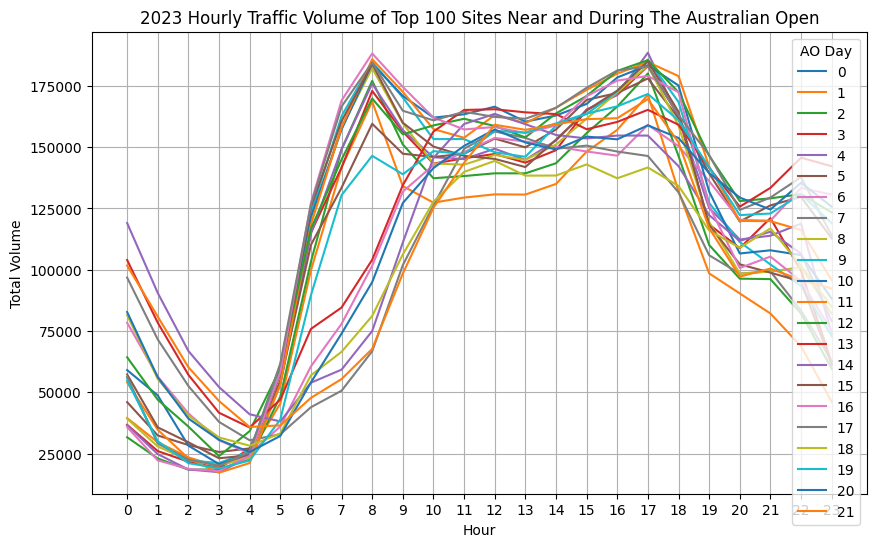

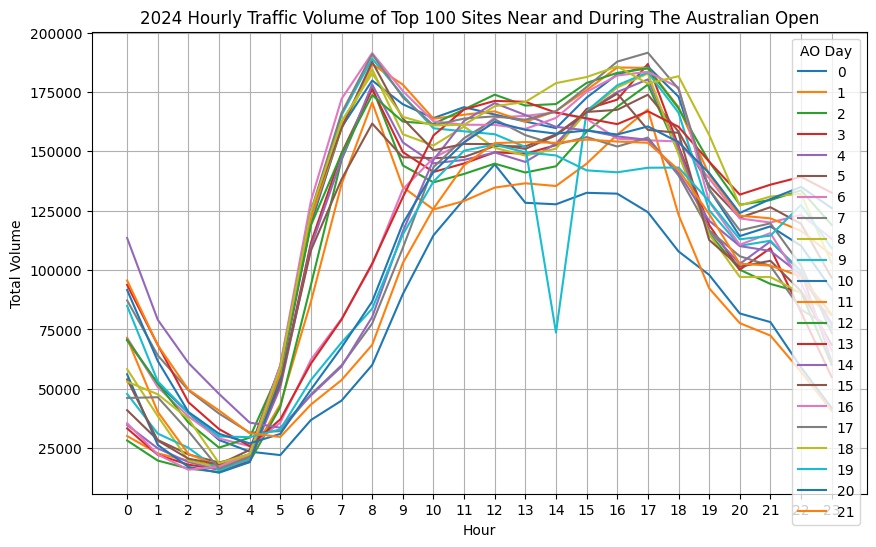

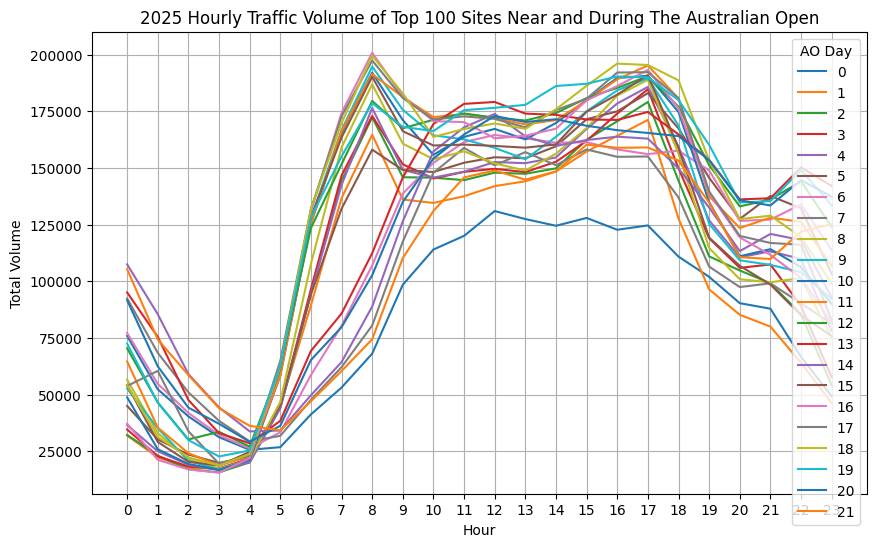

In [4]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE HOURLY TOTAL TRAFFIC VOLUME DURING THE AUSTRALIAN OPEN EACH DAY, EACH YEAR
# ---------------------------------------------------------------------------------------------------------------

# Add year column
hourly_ao_sdf = ao_sdf.withColumn("year", F.year(F.col("date")))

# Add AO day column
ao_dates_sdf = spark.createDataFrame([(year, start) for year, (start, _) in AO_DATES.items()], ["year", "ao_start_date"])
hourly_ao_sdf = hourly_ao_sdf.join(ao_dates_sdf, on="year", how="left")
hourly_ao_sdf = hourly_ao_sdf.withColumn("ao_day", F.when(F.col("year").isin(["2024","2025"]), F.datediff(F.col("date"), F.col("ao_start_date"))) \
                                              .otherwise(F.datediff(F.col("date"), F.col("ao_start_date")) + 1))

# Convert from Spark to Pandas DataFrame
hourly_ao_pdf = hourly_ao_sdf.select("year", "ao_day", "hour", "volume").toPandas().sort_values(["year", "ao_day", "hour"])

# Plot traffic volume
for year in range(2020, 2026):

    year_df = hourly_ao_pdf[hourly_ao_pdf["year"] == year]
    
    plt.figure(figsize=(10, 6))

    for ao_day in range(22):

        ao_day_df = year_df[year_df["ao_day"] == ao_day]

        plt.plot(ao_day_df["hour"], ao_day_df["volume"], label=ao_day)
        plt.xlabel("Hour")
        plt.ylabel("Total Volume")
        plt.title(f"{year} Hourly Traffic Volume of Top 100 Sites Near and During The Australian Open")
        plt.xticks(range(24))
        plt.legend(title="AO Day")
        plt.grid(True)

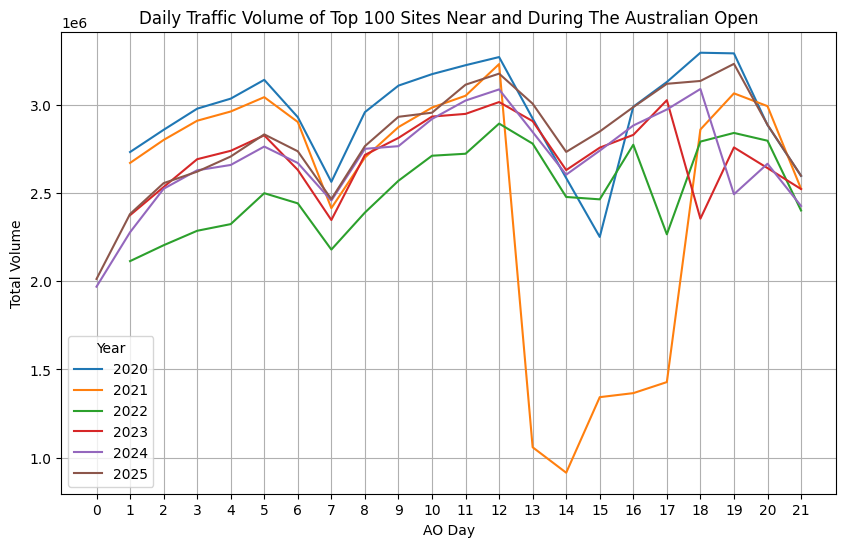

In [5]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE DAILY TOTAL TRAFFIC VOLUME DURING THE AUSTRALIAN OPEN EACH YEAR
# ---------------------------------------------------------------------------------------------------------------

# Sum volume by day
daily_ao_sdf = hourly_ao_sdf.select("year", "ao_day", "volume") \
                      .groupBy(["year", "ao_day"]) \
                      .agg(F.sum("volume").alias("volume")) \
                      .orderBy(["year", "ao_day"])

# Convert from Spark to Pandas DataFrame
daily_ao_pdf = daily_ao_sdf.toPandas()

# Plot traffic volume
plt.figure(figsize=(10, 6))
for year in range(2020, 2026):

    year_df = daily_ao_pdf[daily_ao_pdf["year"] == year]
    
    plt.plot(year_df["ao_day"], year_df["volume"], label=year)
    plt.xlabel("AO Day")
    plt.ylabel("Total Volume")
    plt.title("Daily Traffic Volume of Top 100 Sites Near and During The Australian Open")
    plt.xticks(range(22))
    plt.legend(title="Year")
    plt.grid(True)

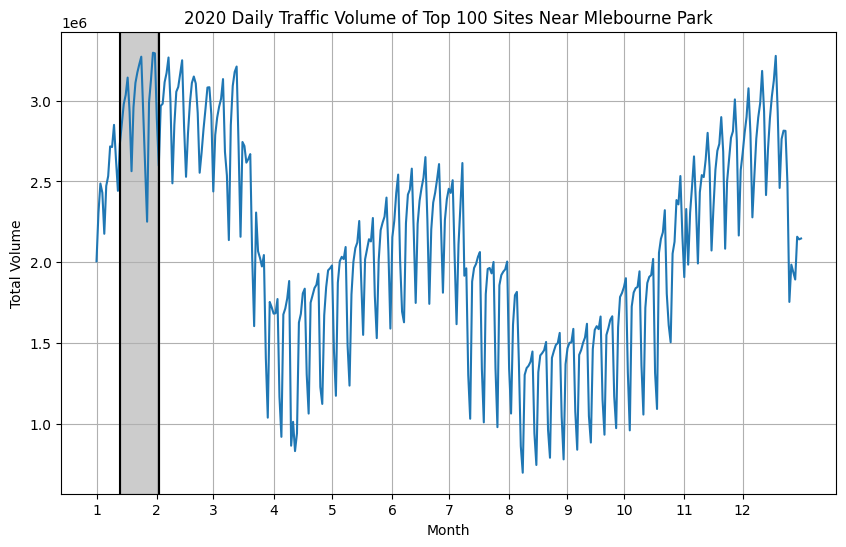

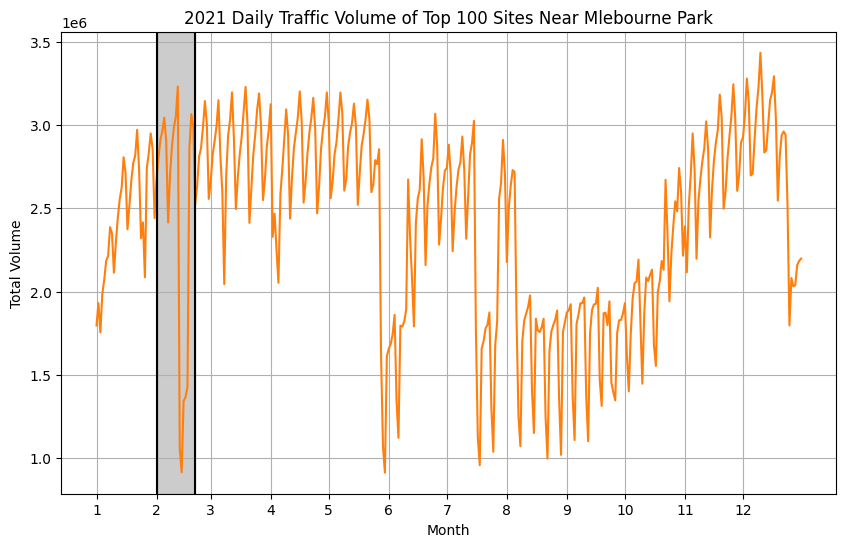

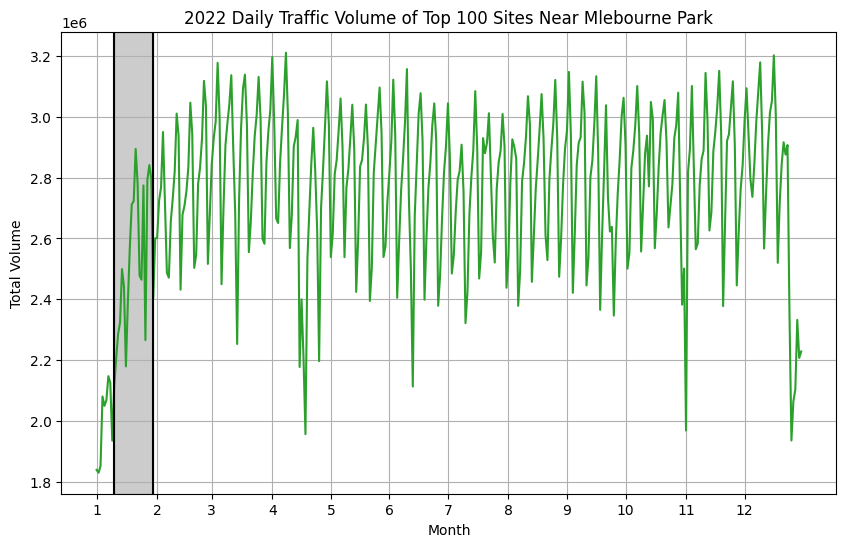

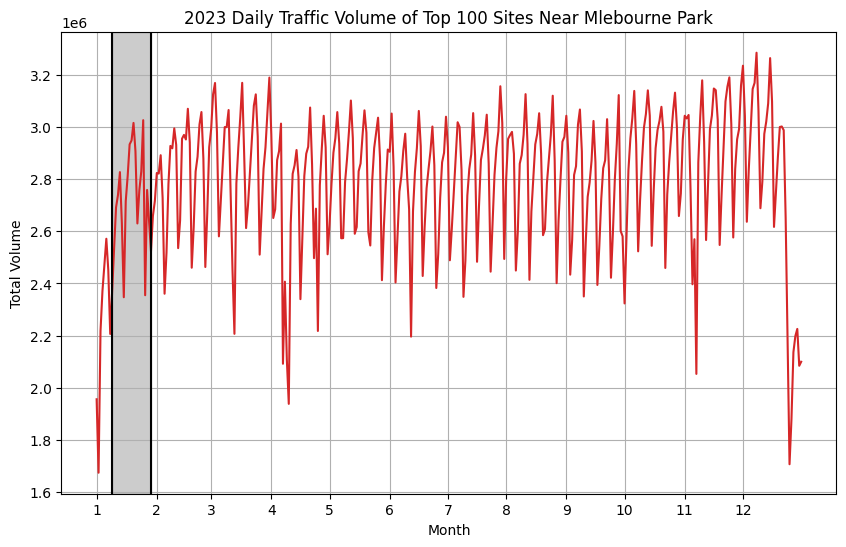

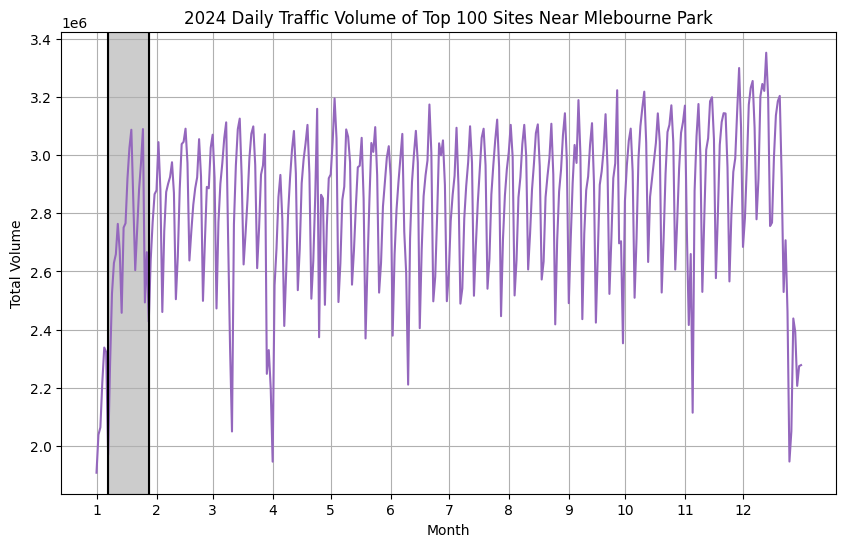

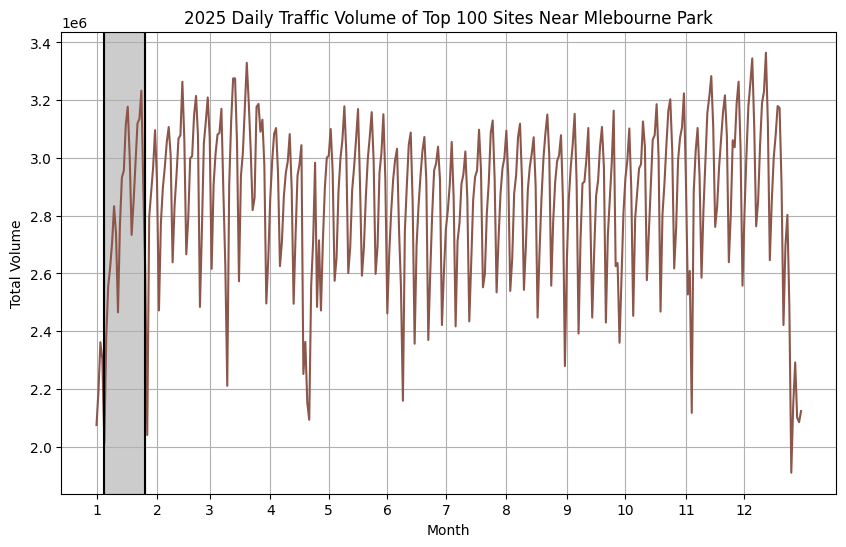

In [6]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE DAILY TOTAL TRAFFIC VOLUME ALL YEAR, EACH YEAR
# ---------------------------------------------------------------------------------------------------------------

# Sum volume by day
daily_sdf = sdf.select("date", "volume") \
                      .groupBy("date") \
                      .agg(F.sum("volume").alias("volume")) \
                      .orderBy("date")
                
# Add date columns
daily_sdf = daily_sdf.withColumn("year", F.year(F.col("date")))
daily_sdf = daily_sdf.withColumn("month_day", F.date_format(F.col("date"), "MM-dd"))

# Convert from Spark to Pandas DataFrame
daily_pdf = daily_sdf.toPandas().sort_values(["year", "month_day"])

# Remove outlier
daily_pdf = daily_pdf[daily_pdf["volume"] < 5000000] # on 2022-08-05

# Plot traffic volume
for i, year in enumerate(range(2020, 2026)):

    year_df = daily_pdf[daily_pdf["year"] == year]
    
    plt.figure(figsize=(10, 6))
    plt.plot(year_df["month_day"], year_df["volume"], color=COLORS[i])

    start_date = AO_DATES[year][0].strftime("%m-%d")
    end_date = AO_DATES[year][1].strftime("%m-%d")
    
    plt.axvline(start_date, color="black")
    plt.axvline(end_date, color="black")
    plt.axvspan(start_date, end_date, color="black", alpha=0.2)

    plt.xlabel("Month")
    plt.ylabel("Total Volume")
    plt.title(f"{year} Daily Traffic Volume of Top 100 Sites Near Mlebourne Park")
    plt.xticks(MONTH_STARTS, labels=range(1,13))
    plt.grid(True)

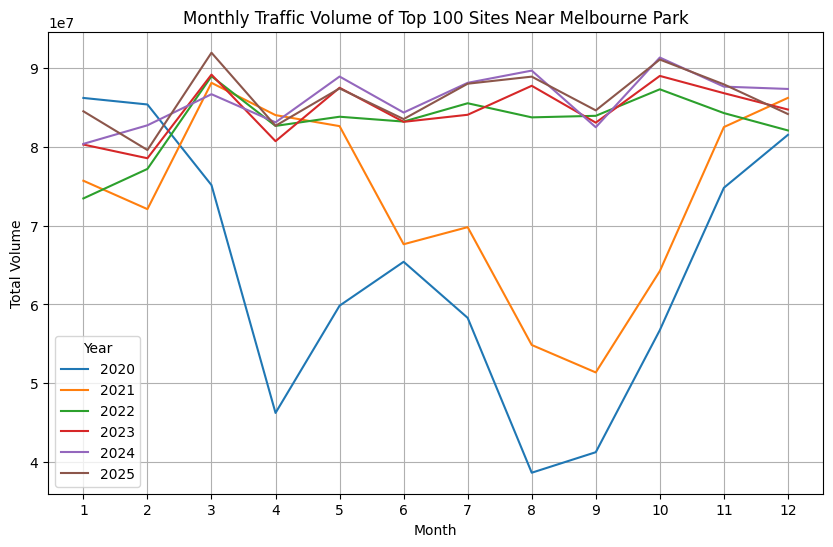

In [7]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE MONTHLY TOTAL TRAFFIC VOLUME EACH YEAR
# ---------------------------------------------------------------------------------------------------------------

# Sum volume by month
daily_pdf["date"] = pd.to_datetime(daily_pdf["date"])
daily_pdf["month"] = daily_pdf["date"].dt.month
daily_pdf = daily_pdf[["year", "month", "volume"]].groupby(["year", "month"], as_index=False).sum()

# Plot traffic volume
plt.figure(figsize=(10, 6))

for year in range(2020, 2026):

    year_df = daily_pdf[daily_pdf["year"] == year]

    plt.plot(year_df["month"], year_df["volume"], label=year)
    
plt.xlabel("Month")
plt.ylabel("Total Volume")
plt.title("Monthly Traffic Volume of Top 100 Sites Near Melbourne Park")
plt.xticks(range(1,13))
plt.legend(title="Year")
plt.grid(True)